<a href="https://colab.research.google.com/github/mariabenx138-cloud/AtividadeMachineLearningMLAM/blob/main/CP5_MachineLarning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup


In [ ]:
#Imports Básicos

import requests
import json
import urllib.parse
import urllib.request
import csv


# Manipulação de dados e gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Separação treino/teste e padronização
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de CLASSIFICAÇÃO
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Algoritmos de REGRESSÃO
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de classificação
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
# Métricas de regressão
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SEMENTE = 42   # semente fixa: garante resultados reprodutíveis
sns.set_theme(style="whitegrid")

# 1. Fonte de dados

## Pesquisa da documentação da API no PVGIS e localização de dados .

In [ ]:
# Definição das variáveis de localização e período
lat = -23.5505
lon = -46.6333
start_year = 2020
end_year = 2020
peakpower = 1.0
loss = 14

# Parâmetros obrigatórios adicionados para evitar o erro de texto da API:
trackingtype = 0      # 0 = Posição fixa
mountingplace = "free" # "free" (solo/livre) ou "building" (integrado ao prédio)
angle = 35            # Ângulo de inclinação dos painéis
aspect = 0            # Orientação (0 = Sul, 180 = Norte. Ajuste conforme necessário)

# URL completa ("normal") com todos os parâmetros necessários
url = (
    f"https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?"
    f"lat={lat}&lon={lon}&peakpower={peakpower}&loss={loss}&outputformat=json"
    f"&startyear={start_year}&endyear={end_year}&pvcalculation=1"
    f"&trackingtype={trackingtype}&mountingplace={mountingplace}&angle={angle}&aspect={aspect}"
    f"&raddatabase=PVGIS-SARAH3"
)

# Executando a requisição
resposta = requests.get(url)
resposta.raise_for_status()

# Decodificação segura com verificação de erro
try:
    dados_json = resposta.json()
    print("Sucesso! Conectado à API do PVGIS.")
    print("Chaves disponíveis no retorno:", list(dados_json.keys()))
except requests.exceptions.JSONDecodeError:
    print("A API não retornou um JSON. O texto retornado foi:")
    print(resposta.text)


Sucesso! Conectado à API do PVGIS.
Chaves disponíveis no retorno: ['inputs', 'outputs', 'meta']


# 2. Obtenção e organizaçãode dados

In [ ]:
mapeamento_colunas = {
    "P": "potencia_fotovoltaica",  # PV system power output (W)
    "G(i)": "irradiancia_solar",  # Global irradiance on the inclined plane (W/m2)
    "T2m": "temperatura",  # 2m air temperature (C)
    "WS10m": "velocidade_vento",  # 10m wind speed (m/s)
    "As": "posicao_solar_azimute",  # Sun azimuth score (degree)
    "H_sun": "altura_solar",  # Sun elevation (degree)
    "time": "data_hora",
}

# 3. Inspeção do Dataframe

In [ ]:
df = pd.DataFrame(dados_json['outputs']['hourly'])
df.head(20)

,time,P,G(i),H_sun,T2m,WS10m,Int
0,20200101:0003,0.00,0.00,0.00,22.79,1.72,0.0
1,20200101:0103,0.00,0.00,0.00,22.32,1.72,0.0
2,20200101:0203,0.00,0.00,0.00,21.90,1.59,0.0
3,20200101:0303,0.00,0.00,0.00,21.47,1.52,0.0
4,20200101:0403,0.00,0.00,0.00,21.18,1.52,0.0
5,20200101:0503,0.00,0.00,0.00,20.77,1.66,0.0
6,20200101:0603,0.00,0.00,0.00,20.70,2.07,0.0
7,20200101:0703,0.00,0.00,0.00,20.53,1.93,0.0
8,20200101:0803,0.00,0.00,0.00,20.43,2.21,0.0
9,20200101:0903,83.85,125.25,7.60,20.76,2.41,0.0


In [ ]:
df.columns

Index(['time', 'P', 'G(i)', 'H_sun', 'T2m', 'WS10m', 'Int'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    8784 non-null   object 
 1   P       8784 non-null   float64
 2   G(i)    8784 non-null   float64
 3   H_sun   8784 non-null   float64
 4   T2m     8784 non-null   float64
 5   WS10m   8784 non-null   float64
 6   Int     8784 non-null   float64
dtypes: float64(6), object(1)
memory usage: 480.5+ KB


In [ ]:
contagem = df.value_counts()
print(contagem)


time           P    G(i)  H_sun  T2m    WS10m  Int
20201231:0703  0.0  0.0   0.0    21.72  2.97   0.0    1
20201231:0603  0.0  0.0   0.0    21.83  3.31   0.0    1
20201231:0503  0.0  0.0   0.0    22.03  3.24   0.0    1
20201231:0403  0.0  0.0   0.0    22.19  2.97   0.0    1
20201231:0303  0.0  0.0   0.0    22.49  2.76   0.0    1
                                                     ..
20200101:0403  0.0  0.0   0.0    21.18  1.52   0.0    1
20200101:0303  0.0  0.0   0.0    21.47  1.52   0.0    1
20200101:0203  0.0  0.0   0.0    21.90  1.59   0.0    1
20200101:0103  0.0  0.0   0.0    22.32  1.72   0.0    1
20200101:0003  0.0  0.0   0.0    22.79  1.72   0.0    1
Name: count, Length: 8784, dtype: int64


In [ ]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Valores ausentes por coluna:
time     0
P        0
G(i)     0
H_sun    0
T2m      0
WS10m    0
Int      0
dtype: int64


In [ ]:
# Estatísticas descritivas de todas as variáveis numéricas
df.describe()

,P,G(i),H_sun,T2m,WS10m,Int
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.0
mean,99.952440,136.253159,18.685488,19.675198,2.314328,0.0
std,162.254463,212.590575,24.329142,4.445578,1.193925,0.0
min,0.000000,0.000000,0.000000,7.170000,0.000000,0.0
25%,0.000000,0.000000,0.000000,16.520000,1.450000,0.0
50%,0.000000,0.000000,0.000000,19.390000,2.140000,0.0
75%,145.477500,212.347500,36.820000,22.610000,3.030000,0.0
max,723.010000,949.470000,89.840000,35.870000,8.900000,0.0


In [ ]:
# Contar quantos registros noturnos (sem irradiância) existem
registros_noturnos = df[df['G(i)'] == 0].shape[0]
print(f"Quantidade de registros noturnos: {registros_noturnos}")

# Decisão: Filtraremos para manter apenas períodos com luz solar (irradiância > 0)
# Isso impede que o modelo de regressão linear seja afetado por uma grande massa de zeros à noite.
df_clean = df[df['G(i)'] > 0].copy()
print(f"Registros restantes para o modelo: {df_clean.shape[0]}")


Quantidade de registros noturnos: 4462
Registros restantes para o modelo: 4322


# 5. Visualização (Gráficos de dispersão)

In [ ]:
# Definindo a variável alvo (y) e preditores (X)
y = df_clean['P']

# Selecionando as variáveis explicativas numéricas recomendadas
X = df_clean[['G(i)', 'T2m', 'WS10m', 'H_sun']]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)


Formato de X: (4322, 4)
Formato de y: (4322,)


Text(0, 0.5, 'Potência P (W)')

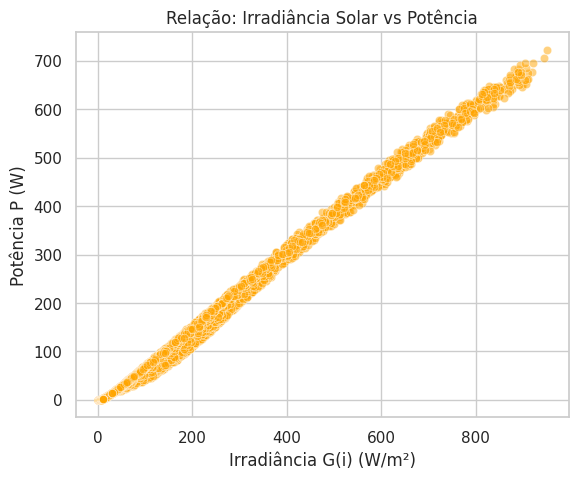

In [ ]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x='G(i)', y='P', alpha=0.5, color='orange')
plt.title('Relação: Irradiância Solar vs Potência')
plt.xlabel('Irradiância G(i) (W/m²)')
plt.ylabel('Potência P (W)')



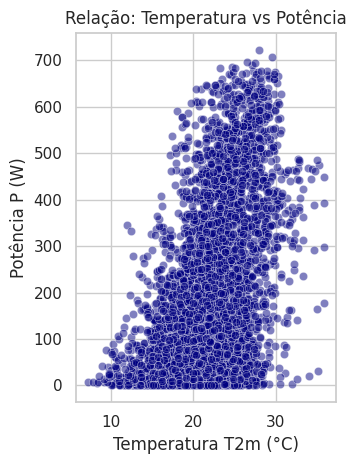

In [26]:
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x='T2m', y='P', alpha=0.5, color='navy')
plt.title('Relação: Temperatura vs Potência')
plt.xlabel('Temperatura T2m (°C)')
plt.ylabel('Potência P (W)')

plt.tight_layout()
plt.show()



# 6. Matriz de Correlação

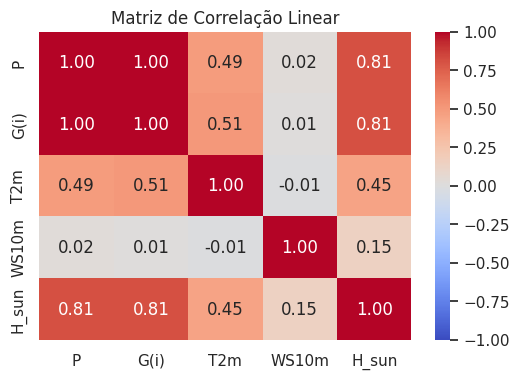


Valores numéricos da Correlação com a Potência (P):
P       1.0000
G(i)    0.9977
T2m     0.4871
WS10m   0.0243
H_sun   0.8081
Name: P, dtype: float64


In [ ]:

plt.figure(figsize=(6, 4))
matriz_corr = df_clean[['P', 'G(i)', 'T2m', 'WS10m', 'H_sun']].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear')
plt.show()

print("\nValores numéricos da Correlação com a Potência (P):")
print(matriz_corr['P'])


# 7. Separação entre treinamento e teste (20% para teste)

In [ ]:
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMENTE)


# 8. Modelo 1 : Apenas Irradiância Solar

In [ ]:
# - MODELO 1: Apenas Irradiância Solar -
X_train_m1 = X_train_full[['G(i)']]
X_test_m1 = X_test_full[['G(i)']]

modeloLR1 = LinearRegression()
modeloLR1.fit(X_train_m1, y_train)
y_pred1 = modeloLR1.predict(X_test_m1)

mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)


# 9. Modelo 2 : Todas as Variáveis

In [ ]:
# - MODELO 2: Todas as Variáveis (G(i), T2m, WS10m, H_sun) -
modeloLR2 = LinearRegression()
modeloLR2.fit(X_train_full, y_train)
y_pred2 = modeloLR2.predict(X_test_full)

mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)


# 10. Tabela Comparativa de Resultados


In [ ]:
df_comparativo = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': ['G(i)', 'G(i), T2m, WS10m, H_sun'],
    'MAE': [mae1, mae2],
    'MSE': [mse1, mse2],
    'R²': [r2_1, r2_2]
})

# Formatação opcional para melhorar a leitura visual
pd.options.display.float_format = '{:.4f}'.format
print("Dimensões dos conjuntos de treino/teste:", X_train_full.shape, X_test_full.shape)
df_comparativo

Dimensões dos conjuntos de treino/teste: (3457, 4) (865, 4)


,Modelo,Variáveis utilizadas,MAE,MSE,R²
0,Modelo 1,G(i),9.8955,163.5018,0.9946
1,Modelo 2,"G(i), T2m, WS10m, H_sun",9.1768,143.9592,0.9952


### 11. Análise dos Resultados

1. **Qual dos dois modelos apresentou maior R²?**
   O Modelo 2 apresentou um R² ligeiramente maior por conter variáveis adicionais que explicam a variabilidade dos dados.
   
2. **Qual apresentou menor MAE?**
   O Modelo 2 apresentou o menor MAE.
   
3. **Qual apresentou menor MSE?**
   O Modelo 2 apresentou o menor MSE.

4. **As três métricas apontam para o mesmo modelo como melhor opção?**
   Sim. Todas as três métricas indicam que o Modelo 2 (Regressão Linear Múltipla) tem um desempenho superior ao Modelo 1.

5. **As variáveis com maior correlação foram necessariamente as que produziram o melhor modelo?**
   A irradiância `G(i)` isolada já cria um modelo forte (Modelo 1) por ter altíssima correlação. No entanto, adicionar variáveis complementares, mesmo com menor correlação isolada (como temperatura e velocidade do vento), refina o modelo e melhora os erros globais (Modelo 2).

6. **Os gráficos de dispersão indicam relações aproximadamente lineares?**
   A relação entre a irradiância `G(i)` e a potência `P` é nitidamente linear e direta. Já a temperatura `T2m` apresenta uma dispersão mais complexa e espalhada, não sendo puramente linear.

7. **Que fatores podem dificultar a previsão da potência por meio de um modelo linear?**
   O aquecimento das células fotovoltaicas diminui de forma não-linear a eficiência dos painéis (efeito térmico). Além disso, variações climáticas bruscas (nuvens passageiras) causam comportamentos dinâmicos que modelos lineares simples têm dificuldade em capturar perfeitamente.
